In [ ]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

In [ ]:
input_path = '/storage/shared/oceanparcels/input_data/MOi/GLO12/'

file_name = 'psy4v3r1-daily_U_2014-10-01.nc'

dataset_U = xr.open_dataset(input_path + file_name)

dataset_U

<xarray.Dataset> Size: 6GB
Dimensions:       (y: 3059, x: 4322, deptht: 50)
Coordinates:
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
  * x             (x) int32 17kB 1 2 3 4 5 6 7 ... 4317 4318 4319 4320 4321 4322
  * y             (y) int32 12kB 1 2 3 4 5 6 7 ... 3054 3055 3056 3057 3058 3059
    time_counter  datetime64[ns] 8B ...
  * deptht        (deptht) float64 400B 0.494 1.541 ... 5.275e+03 5.728e+03
Data variables:
    sotkeavmu1    (y, x) float64 106MB ...
    sotkeavmu15   (y, x) float64 106MB ...
    sotkeavmu30   (y, x) float64 106MB ...
    sotkeavmu50   (y, x) float64 106MB ...
    vozocrtx      (deptht, y, x) float64 5GB ...
Attributes:
    Conventions:  CF-1.0
    file_name:    ORCA12_LIM-T00_y2021m10d25_gridU.nc
    institution:  MERCATOR OCEAN
    source:       NEMO
    TimeStamp:    2021-OCT-31 18:25:03 GMT-0000
    references:   http://www.mercator-ocean.eu

In [19]:
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'
phy_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc' 
phy_files_U = []
phy_files_V = []

starttime = datetime(2024,11,1)
endtime = datetime(2025,1,1)
dtime = timedelta(days=1)    #je stelt hier handmatig in wat de tijdsresolutie is van je data
time = starttime
phy_file_W = directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc'.format(vector = 'W', y = time.year, m = time.month, d = time.day)
while(time < endtime):
    phy_files_U.append(phy_base_file.format(vector = 'U', y = time.year, m = time.month, d = time.day))
    phy_files_V.append(phy_base_file.format(vector = 'V', y = time.year, m = time.month, d = time.day))
    time+=dtime

# pprint.pprint(phy_files_U)

mesh_file_h = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_hgr.nc"   #Hiermee converteren we het grid!
mesh_file_z = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_zgr.nc"
filenames_phy = {'U': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_U,
    }, 'V': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_V,
    }
}
variables_phy = {'U': 'vozocrtx',
                'V': 'vomecrty'}

c_grid_dimensions = {'lat': 'gphif',
                 'lon': 'glamf',
                 'depth':'depthw',
                 'time': 'time_counter'}

dimensions_phy = {'U': c_grid_dimensions,
                 'V': c_grid_dimensions}

fieldset = parcels.FieldSet.from_nemo(filenames=filenames_phy,variables=variables_phy,dimensions=dimensions_phy)

In [ ]:
print(starttime)
print(np.shape(fieldset.U))

print(fieldset.U.time)

2024-11-01 00:00:00
()
<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[ 72.96,  73.04,  73.12, ...,  72.88,  72.96,  73.04],
               [ 72.96,  73.04,  73.12, ...,  72.88,  72.96,  73.04],
               [ 72.96,  73.04,  73.12, ...,  72.88,  72.96,  73.04],
               ...,
               [ 73.00,  73.00,  73.00, ...,  73.00,  73.00,  73.00],
               [ 73.00,  73.00,  73.00, ...,  73.00,  73.00,  73.00],
               [ 73.00,  73.00,  73.00, ...,  73.00,  73.00,  73.00]], shape=(3059, 4322), dtype=float32), lat=array([[-77.00, -77.00, -77.00, ..., -77.00, -77.00, -77.00],
               [-76.98, -76.98, -76.98, ..., -76.98, -76.98, -76.98],
               [-76.96, -76.96, -76.96, ..., -76.96, -76.96, -76.96],
               ...,
               [ 50.00,  50.00,  50.00, ...,  50.00,  50.00,  50.00],
               [ 50.00,  50.00,  50.00, ...,  50.00,  50.00,  50.00],
               [ 5

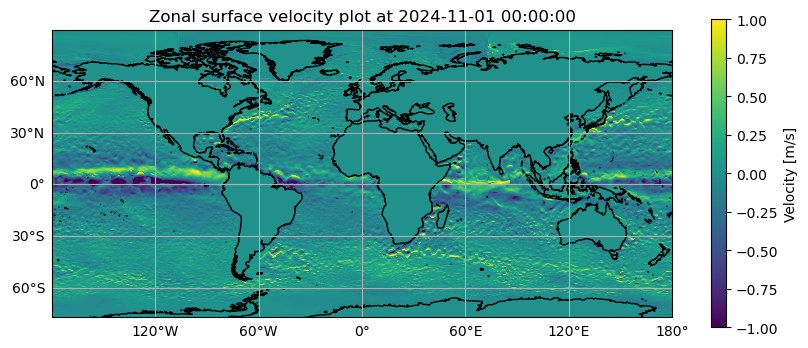

In [ ]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, 0, :,:], vmin=-1, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal surface velocity plot at {starttime}')
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

In [ ]:
print(np.shape(fieldset.U.data))

(2, 50, 3059, 4322)
[0. 0.]


/tmp/ipykernel_4718/3765416582.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 2 Axes> than <Figure size 1000x800 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(vplot, ax=ax, shrink = 0.5)


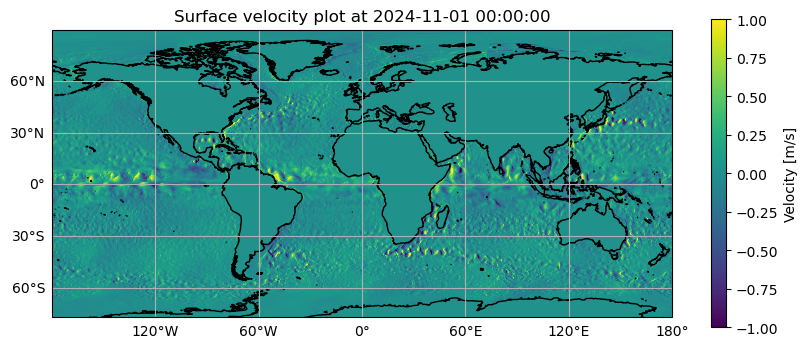

In [ ]:
fig2 = plt.figure(figsize = (10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.V.data[0, 0, :,:], vmin=-1, vmax=1, transform=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Meridional surface velocity plot at {starttime}')
cbar = fig.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

/tmp/ipykernel_14500/207610142.py:9: UserWarning: Adding colorbar to a different Figure <Figure size 1000x700 with 2 Axes> than <Figure size 1200x400 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(vplot, ax=ax, shrink = 0.5)


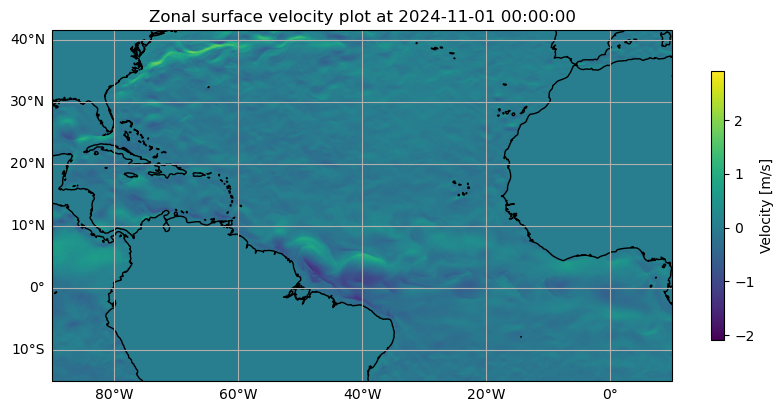

In [ ]:
fig3 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, 0, :,:], transform=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal surface velocity plot at {starttime}')
ax.set_extent([-90,10,-10,30])
cbar = fig3.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

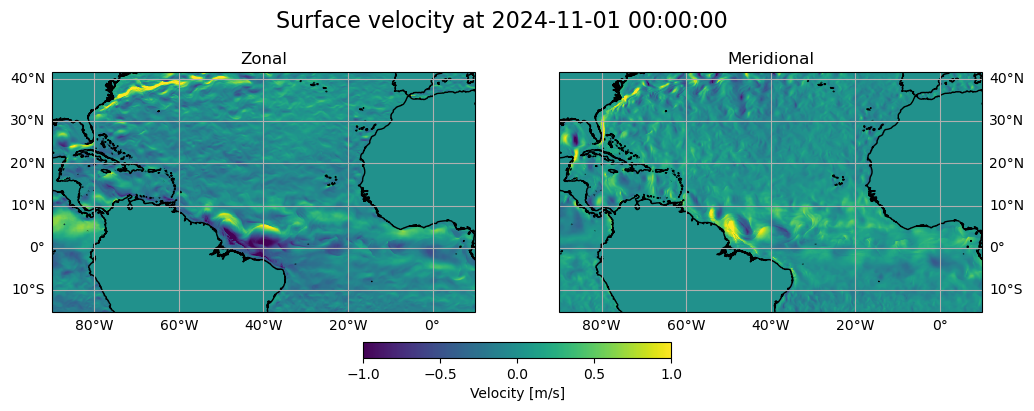

In [ ]:
#Plotting zonal and meridionalvelocity field of first timestep
fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={'projection': ccrs.PlateCarree()})

#Plot 1: Zonal velocity (U)
vplot1 = axes[0].pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, 0, :, :],
                            vmin=-1, vmax=1, transform=ccrs.PlateCarree())
axes[0].add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
axes[0].add_feature(cartopy.feature.LAND.with_scale('10m'))
axes[0].gridlines(draw_labels=['left','bottom'], zorder=0)
axes[0].set_title(f'Zonal')
axes[0].set_extent([-90, 10, -10, 30])

#Plot 2: Meridional velocity (V)
vplot2 = axes[1].pcolormesh(fieldset.V.grid.lon, fieldset.V.grid.lat, fieldset.V.data[0, 0, :, :],
                            vmin=-1, vmax=1, transform=ccrs.PlateCarree())
axes[1].add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
axes[1].add_feature(cartopy.feature.LAND.with_scale('10m'))
axes[1].gridlines(draw_labels=['right','bottom'], zorder=0)
axes[1].set_title(f'Meridional')
axes[1].set_extent([-90, 10, -10, 30])

fig.suptitle(f'Surface velocity at {starttime}', fontsize=16)

#Shared colorbar underneath
cbar = fig.colorbar(vplot1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('Velocity [m/s]')
plt.tight_layout()
plt.show()

In [ ]:
# Define a new particleclass with Variable 'age' with initial value 0.
AgeParticle = parcels.JITParticle.add_variable(parcels.Variable("age", initial=0))

pset = parcels.ParticleSet(
    fieldset=fieldset,  # the fields that the particleset uses
    pclass=AgeParticle,  # define the type of particle
    lon=29,  # release longitude
    lat=-33,  # release latitude
)

In [ ]:
#Creating a kernel which keeps track of particle age
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600


#Define all kernels to be executed on particles using an (ordered) list
kernels = [Age, NorthVel, parcels.AdvectionRK4]